<a href="https://colab.research.google.com/github/sebitajuniorprogramax-byte/Wine-Analytics-Project/blob/main/AnalisisdeVino.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#1. Instalar la libreria de Kaggle
!pip install opendatasets

import opendatasets as od
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#2. Descargar el dataset (pedirá usuario y "key" de Kaggle)
#Ve a Kaggle -> Your Account -> API -> Create New API Token
#Esto descargará un archivo kaggle.json
od.download("https://www.kaggle.com/datasets/zynicide/wine-reviews")

#3. Cargar los datos en un DataFrame de pandas
#El archivo está dentro de la carpeta 'wine-reviews'
file_path = 'wine-reviews/winemag-data-130k-v2.csv'
df = pd.read_csv(file_path, index_col=0) # Usamos index_col=0 porque la primera columna es el índice

#4. Configurar seaborn para gráficos más bonitos
sns.set(style="whitegrid")


In [ ]:
#Ver las primeras 5 filas
print(df.head())

#Ver la información general (tipos de datos y valores nulos)
print(df.info())

#Conteo de valores nulos (missing data)
print(df.isna().sum())

#Para este análisis, nos interesan precio y país.
#Eliminemos filas donde 'price', 'country' o 'variety' sean nulos
df_clean = df.dropna(subset=['price', 'country', 'variety'])

    country                                        description  \
0     Italy  Aromas include tropical fruit, broom, brimston...   
1  Portugal  This is ripe and fruity, a wine that is smooth...   
2        US  Tart and snappy, the flavors of lime flesh and...   
3        US  Pineapple rind, lemon pith and orange blossom ...   
4        US  Much like the regular bottling from 2012, this...   

                          designation  points  price           province  \
0                        Vulkà Bianco      87    NaN  Sicily & Sardinia   
1                            Avidagos      87   15.0              Douro   
2                                 NaN      87   14.0             Oregon   
3                Reserve Late Harvest      87   13.0           Michigan   
4  Vintner's Reserve Wild Child Block      87   65.0             Oregon   

              region_1           region_2         taster_name  \
0                 Etna                NaN       Kerin O’Keefe   
1                  NaN

country
US           54265
France       17776
Italy        16914
Spain         6573
Portugal      4875
Chile         4415
Argentina     3756
Austria       2799
Australia     2294
Germany       2120
Name: count, dtype: int64


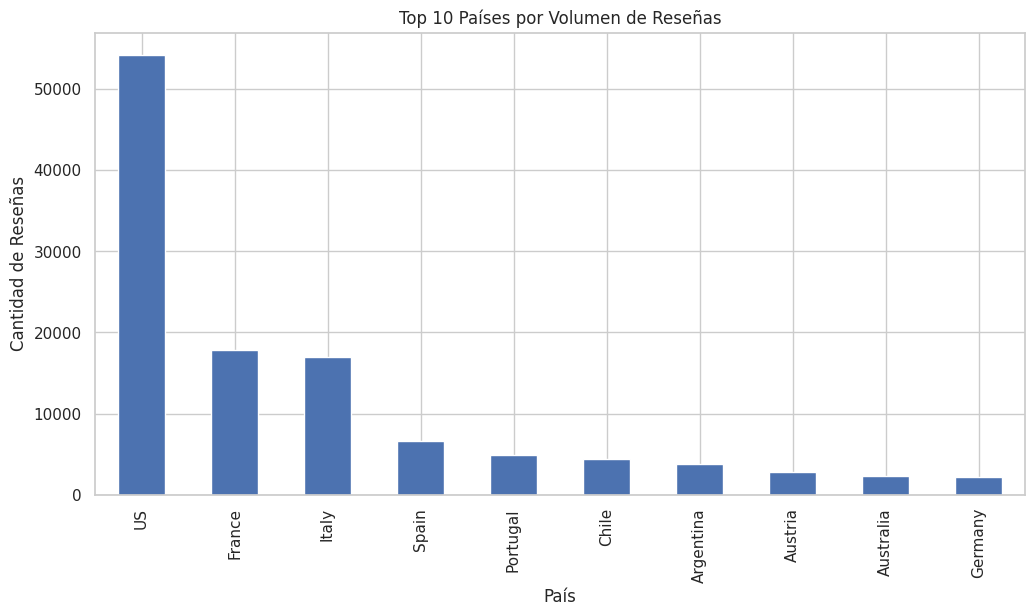

In [ ]:
# Contar los valores por país y tomar los 10 primeros
top_10_countries = df_clean['country'].value_counts().head(10)

print(top_10_countries)

# Visualización
plt.figure(figsize=(12, 6))
top_10_countries.plot(kind='bar')
plt.title('Top 10 Países por Volumen de Reseñas')
plt.xlabel('País')
plt.ylabel('Cantidad de Reseñas')
plt.show()

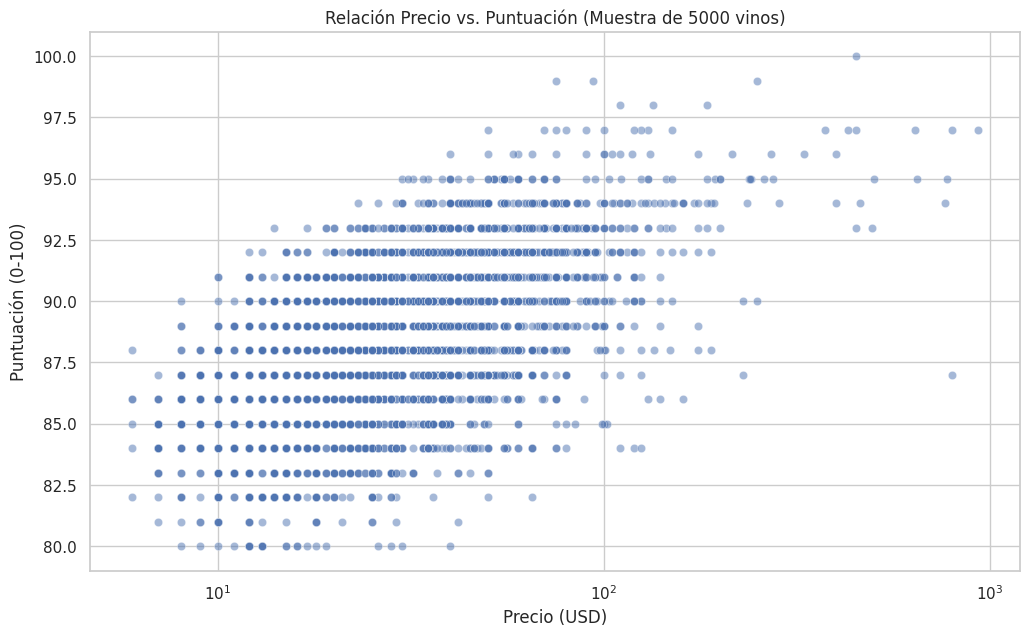

In [ ]:
# Usamos un scatter plot (gráfico de dispersión)
# Tomamos una muestra (sample) de 5000 puntos para que el gráfico sea más rápido
df_sample = df_clean.sample(5000)

plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_sample, x='price', y='points', alpha=0.5)
plt.title('Relación Precio vs. Puntuación (Muestra de 5000 vinos)')
plt.xlabel('Precio (USD)')
plt.ylabel('Puntuación (0-100)')
plt.xscale('log') # Usamos escala logarítmica para el precio, ya que algunos vinos son MUY caros
plt.show()

country
Austria      90.190782
Germany      89.836321
France       88.734867
Italy        88.618186
Australia    88.595466
US           88.566387
Portugal     88.316718
Spain        87.290735
Argentina    86.710330
Chile        86.495130
Name: points, dtype: float64


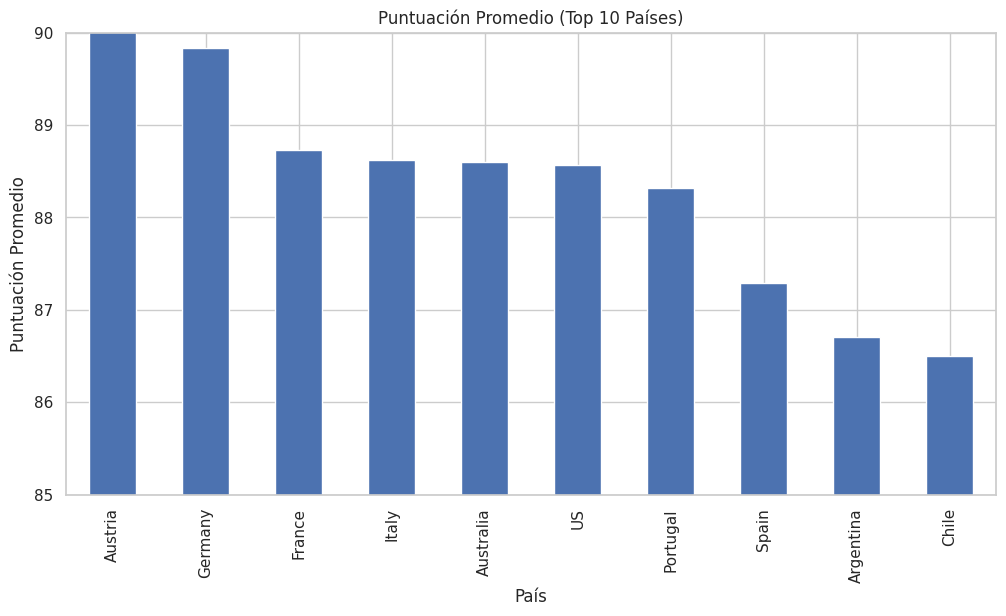

In [ ]:
# Agrupar por país y calcular la media de 'points'
country_mean_points = df_clean.groupby('country')['points'].mean()

# Filtrar solo los países que están en nuestro 'top_10_countries'
top_countries_avg_points = country_mean_points.loc[top_10_countries.index].sort_values(ascending=False)

print(top_countries_avg_points)

# Visualización
plt.figure(figsize=(12, 6))
top_countries_avg_points.plot(kind='bar')
plt.title('Puntuación Promedio (Top 10 Países)')
plt.xlabel('País')
plt.ylabel('Puntuación Promedio')
plt.ylim(85, 90) # Ajustamos el eje Y para ver mejor la diferencia
plt.show()

variety
Champagne Blend                  70.744839
Sangiovese Grosso                65.634975
Nebbiolo                         65.609610
Port                             64.679359
Cabernet Sauvignon               47.944267
Corvina, Rondinella, Molinara    47.907258
Pinot Noir                       47.532734
Bordeaux-style Red Blend         47.210861
Tinta de Toro                    45.357576
Sangiovese                       45.279344
Name: price, dtype: float64


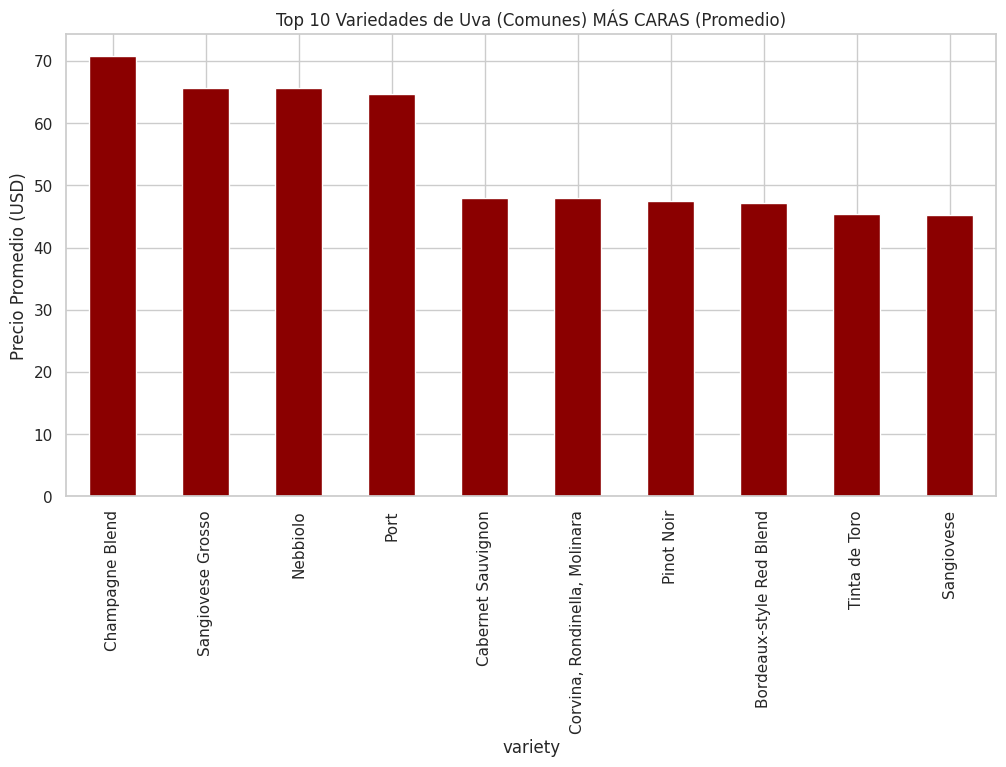

In [ ]:
# 1. Contar cuántas veces aparece cada variedad
variety_counts = df_clean['variety'].value_counts()

# 2. Obtener la lista de variedades "comunes" (las que aparecen > 100 veces)
common_varieties = variety_counts[variety_counts > 100].index

# 3. Filtrar nuestro DataFrame para quedarnos solo con esas variedades comunes
df_common_varieties = df_clean[df_clean['variety'].isin(common_varieties)]

# 4. Ahora sí, agrupar por variedad y calcular el precio promedio
variety_avg_price = df_common_varieties.groupby('variety')['price'].mean().sort_values(ascending=False)

# Mostrar las 10 más caras
print(variety_avg_price.head(10))

# 5. Visualización
plt.figure(figsize=(12, 6))
variety_avg_price.head(10).plot(kind='bar', color='darkred')
plt.title('Top 10 Variedades de Uva (Comunes) MÁS CARAS (Promedio)')
plt.ylabel('Precio Promedio (USD)')
plt.show()

variety
Riesling                    1138
Chardonnay                   906
Sauvignon Blanc              754
Red Blend                    750
Portuguese Red               484
Pinot Noir                   474
Bordeaux-style Red Blend     467
Cabernet Sauvignon           460
Rosé                         455
Syrah                        393
Name: count, dtype: int64


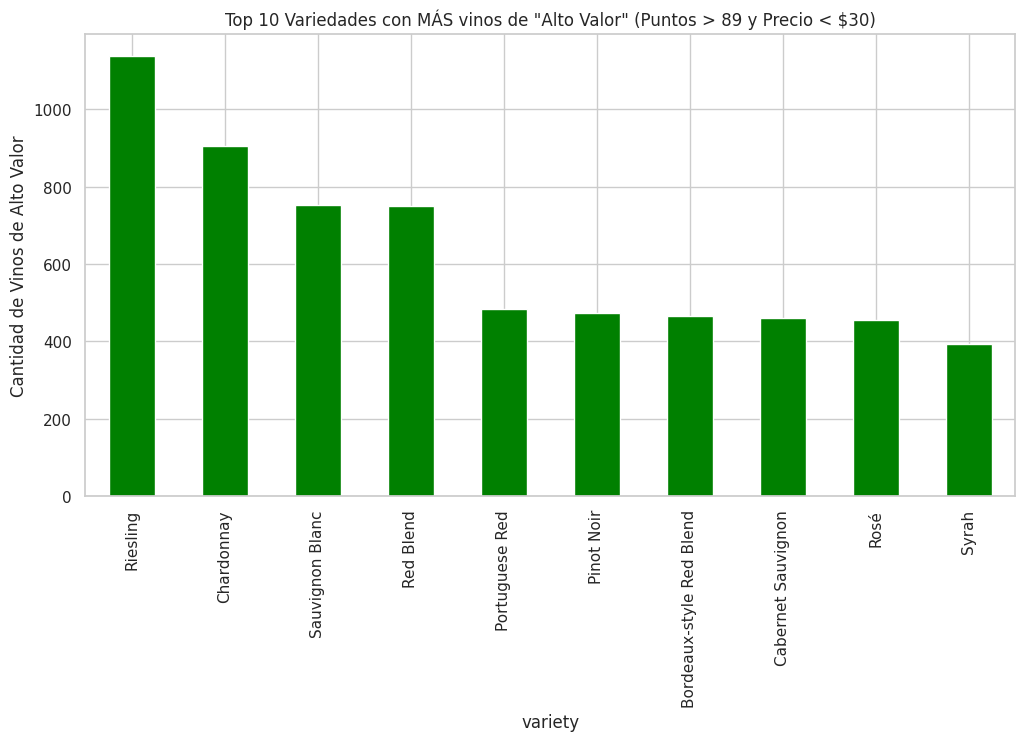

In [ ]:
# 1. Crear un DataFrame solo con vinos de "alto valor"
# Puedes ajustar estos números (points > 89 y price < 30) como quieras
df_value = df_clean[(df_clean['points'] > 89) & (df_clean['price'] < 30)].copy()

# 2. Contar cuáles son las variedades que más aparecen en esta categoría
top_value_varieties = df_value['variety'].value_counts().head(10)

print(top_value_varieties)

# 3. Visualización
plt.figure(figsize=(12, 6))
top_value_varieties.plot(kind='bar', color='green')
plt.title('Top 10 Variedades con MÁS vinos de "Alto Valor" (Puntos > 89 y Precio < $30)')
plt.ylabel('Cantidad de Vinos de Alto Valor')
plt.show()

winery
Lynmar             92.805085
Williams Selyem    92.744076
Foxen              91.676190
Gary Farrell       91.616000
Iron Horse         91.188679
Testarossa         90.741935
Louis Latour       90.705202
Siduri             90.452381
Fess Parker        89.620370
Chehalem           89.313725
Name: points, dtype: float64


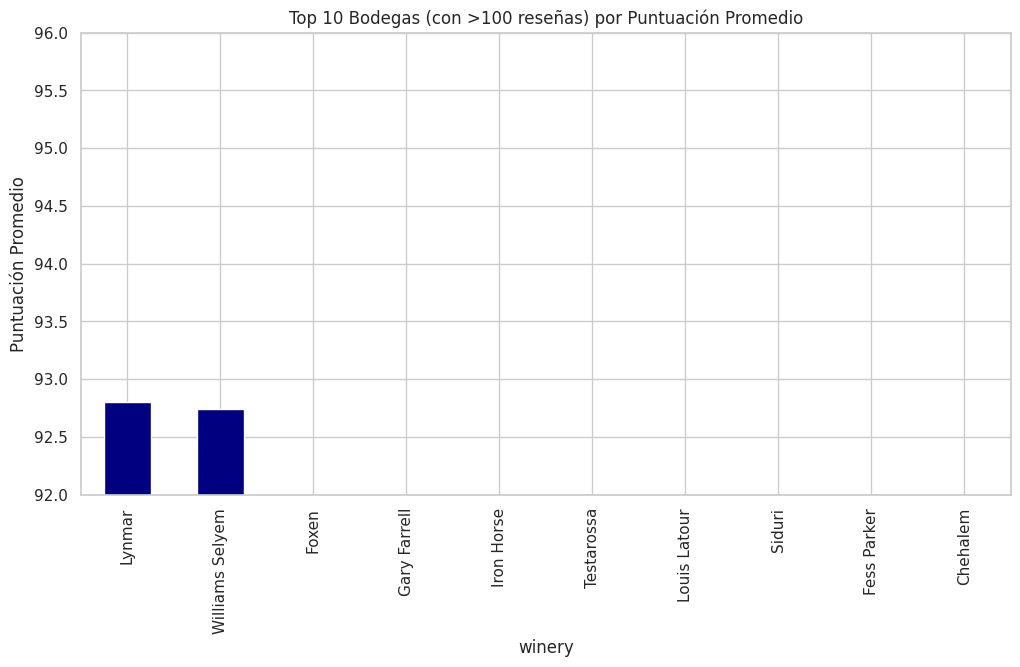

In [ ]:
# 1. Contar cuántas reseñas tiene cada bodega
winery_counts = df_clean['winery'].value_counts()

# 2. Obtener la lista de bodegas "comunes" (las que aparecen > 100 veces)
common_wineries = winery_counts[winery_counts > 100].index

# 3. Filtrar nuestro DataFrame
df_common_wineries = df_clean[df_clean['winery'].isin(common_wineries)]

# 4. Agrupar por bodega y calcular la puntuación promedio
winery_avg_points = df_common_wineries.groupby('winery')['points'].mean().sort_values(ascending=False)

# Mostrar las 10 mejores
print(winery_avg_points.head(10))

# 5. Visualización
plt.figure(figsize=(12, 6))
winery_avg_points.head(10).plot(kind='bar', color='navy')
plt.title('Top 10 Bodegas (con >100 reseñas) por Puntuación Promedio')
plt.ylabel('Puntuación Promedio')
plt.ylim(92, 96) # Ajustamos el eje Y para ver mejor la diferencia
plt.show()

Palabras más comunes en vinos de 95+ puntos:


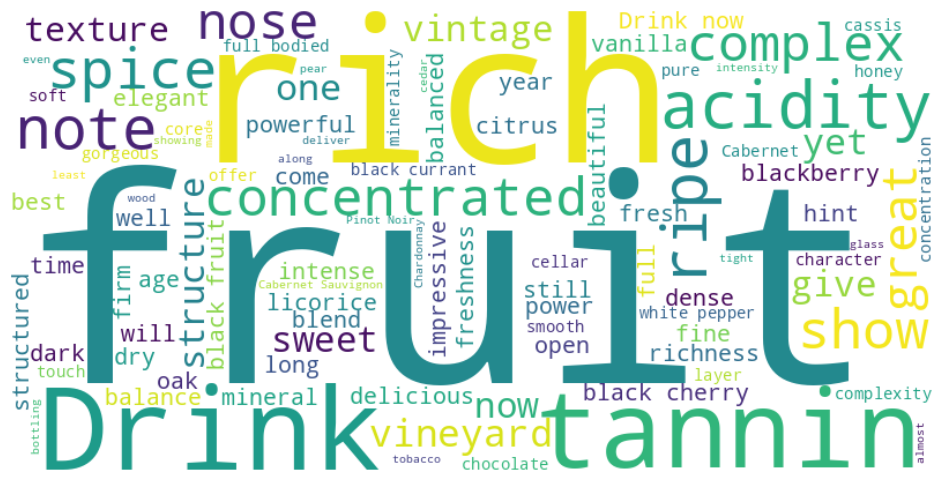

In [ ]:
# 1. Instalar la librería para nubes de palabras
!pip install wordcloud

from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# 2. Preparar los datos
# Filtramos solo vinos con 95 puntos o más
df_premium = df_clean[df_clean['points'] >= 95]

# Juntamos TODAS las descripciones de vinos premium en un solo texto
# (Usamos .astype(str) por si acaso hay algún dato que no sea texto)
text = " ".join(review for review in df_premium.description.astype(str))

# 3. Definir palabras a ignorar (stopwords)
# Añadimos palabras comunes del vino que no nos dan información
stopwords = set(STOPWORDS)
stopwords.update(["wine", "flavor", "flavors", "aroma", "aromas", "finish", "palate", "bottle"])

# 4. Crear la Nube de Palabras
wordcloud = WordCloud(stopwords=stopwords,
                      background_color="white",
                      max_words=100,
                      width=800,
                      height=400).generate(text)

# 5. Mostrar la imagen
print("Palabras más comunes en vinos de 95+ puntos:")
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np

# 1. Preparar los datos
# (Asumimos que 'df_clean' ya no tiene nulos en 'price')

# 2. Definir nuestro objetivo (Target)
# Queremos predecir si un vino es "genial" (1) o no (0)
# Definimos "genial" como 90 puntos o más.
df_clean['is_great'] = np.where(df_clean['points'] >= 90, 1, 0)

# 3. Definir las características (Features)
# Por ahora, usaremos SOLO el precio para predecir.
features = ['price']
X = df_clean[features]
y = df_clean['is_great']

# 4. Dividir los datos (Entrenamiento y Prueba)
# El modelo "aprende" con los datos de train y "presenta examen" con los de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 5. Crear y Entrenar el Modelo
# Usamos un 'RandomForest', que es como un comité de expertos
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# 6. Hacer predicciones y Evaluar
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"\n--- Resultados del Modelo de Machine Learning ---")
print(f"Definición de 'vino genial': {df_clean['is_great'].value_counts(normalize=True)[1]:.1%} (vinos con 90+ puntos)")
print(f"Precisión del modelo (usando solo el precio): {accuracy * 100:.2f}%")
print("--------------------------------------------------")
print(f"Esto significa que el modelo acertó el {accuracy * 100:.2f}% de las veces al predecir si un vino era 'genial' o no, basándose solo en su precio.")

/tmp/ipython-input-1129363355.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['is_great'] = np.where(df_clean['points'] >= 90, 1, 0)



--- Resultados del Modelo de Machine Learning ---
Definición de 'vino genial': 37.5% (vinos con 90+ puntos)
Precisión del modelo (usando solo el precio): 74.75%
--------------------------------------------------
Esto significa que el modelo acertó el 74.75% de las veces al predecir si un vino era 'genial' o no, basándose solo en su precio.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np

# 1. Preparar los datos
# Usamos .copy() para evitar el 'SettingWithCopyWarning' esta vez
df_model = df_clean.copy()

# 2. Definir el Objetivo (Target)
# (1 = Genial (90+ puntos), 0 = No genial)
df_model['is_great'] = np.where(df_model['points'] >= 90, 1, 0)

# --- INGENIERÍA DE CARACTERÍSTICAS (Nuevo) ---
# Queremos evitar crear demasiadas columnas, así que nos quedamos con las categorías top.

# 3. Limpiar Países (Top 10)
top_10_countries = df_model['country'].value_counts().head(10).index
# Si el país no está en el top 10, lo llamamos 'Other'
df_model['country_top'] = df_model['country'].apply(lambda x: x if x in top_10_countries else 'Other')

# 4. Limpiar Variedades (Top 30)
top_30_varieties = df_model['variety'].value_counts().head(30).index
# Si la variedad no está en el top 30, la llamamos 'Other'
df_model['variety_top'] = df_model['variety'].apply(lambda x: x if x in top_30_varieties else 'Other')

# --- PREPARACIÓN DEL MODELO ---

# 5. Definir Características (Features)
# Incluimos precio y nuestras nuevas columnas categóricas
features_to_encode = ['price', 'country_top', 'variety_top']

# 6. Convertir Texto a Números (One-Hot Encoding)
# Esto crea las columnas (1s y 0s) automáticamente
X = pd.get_dummies(df_model[features_to_encode], drop_first=True)
y = df_model['is_great']

# 7. Dividir los datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 8. Entrenar el Modelo
model_v2 = RandomForestClassifier(random_state=42)
model_v2.fit(X_train, y_train)

# 9. Evaluar el Modelo Mejorado
predictions_v2 = model_v2.predict(X_test)
accuracy_v2 = accuracy_score(y_test, predictions_v2)

print(f"\n--- Resultados del Modelo MEJORADO ---")
print(f"Precisión Modelo Anterior (solo precio): 74.75%")
print(f"Precisión Modelo Nuevo (precio + país + variedad): {accuracy_v2 * 100:.2f}%")
print("--------------------------------------------------")

# --- Importancia de las Características (Extra) ---
# ¿Qué le importó más al modelo para tomar su decisión?

importances = model_v2.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Mostrar las 10 características más importantes
print("\nTop 10 Características MÁS IMPORTANTES para el modelo:")
print(feature_importance_df.sort_values(by='Importance', ascending=False).head(10))


--- Resultados del Modelo MEJORADO ---
Precisión Modelo Anterior (solo precio): 74.75%
Precisión Modelo Nuevo (precio + país + variedad): 75.51%
--------------------------------------------------

Top 10 Características MÁS IMPORTANTES para el modelo:
                   Feature  Importance
0                    price    0.810705
25  variety_top_Pinot Noir    0.015958
2      country_top_Austria    0.012665
3        country_top_Chile    0.011000
10          country_top_US    0.010839
30    variety_top_Riesling    0.009626
21       variety_top_Other    0.007672
4       country_top_France    0.007287
14  variety_top_Chardonnay    0.006728
6        country_top_Italy    0.006475


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Preparar los datos
# (Asumimos 'df_clean' de los pasos anteriores)
# Usamos .copy() para evitar warnings
df_mission2 = df_clean.copy()

# 2. Preparar el Objetivo (Target)
# ¡Truco! Predecimos el logaritmo del precio.
# Filtramos precios > 0 para evitar errores con log(0)
df_mission2 = df_mission2[df_mission2['price'] > 0]
df_mission2['log_price'] = np.log(df_mission2['price'])

# 3. Definir Características (X) y Objetivo (y)
features = ['description', 'country', 'variety']
target = 'log_price'

X = df_mission2[features]
y = df_mission2[target]

# 4. Dividir los datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Crear el "Pre-procesador"
# Este es el paso más importante. Le dice a sklearn qué hacer con cada columna.

# Transformador para la columna de TEXTO ('description')
text_transformer = TfidfVectorizer(
    stop_words='english',
    max_features=2000,  # Limitar a las 2000 palabras más importantes
    ngram_range=(1, 2)  # Considerar palabras y pares de palabras (ej. "red fruit")
)

# Transformador para las columnas CATEGÓRICAS ('country', 'variety')
categorical_transformer = OneHotEncoder(
    handle_unknown='ignore',  # Ignorar categorías raras que no vio en el entrenamiento
    sparse_output=False
)

# Unir los transformadores
preprocessor = ColumnTransformer(
    transformers=[
        ('text', text_transformer, 'description'),
        ('cats', categorical_transformer, ['country', 'variety'])
    ],
    remainder='drop'  # Ignorar columnas que no listamos
)

# 6. Crear el Modelo (Regresor)
model_reg = RandomForestRegressor(
    n_estimators=100,  # 100 "árboles de decisión"
    random_state=42,
    n_jobs=-1,         # Usar todos los procesadores de Colab
    max_depth=20       # Limitar la profundidad para evitar sobreajuste
)

# 7. Crear el Pipeline Completo
# El Pipeline conecta todo: 1º pre-procesa, 2º entrena el modelo
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('model', model_reg)])

# 8. Entrenar el Pipeline
print("Entrenando el modelo de regresión... (Esto puede tardar 1-2 minutos)")
pipeline.fit(X_train, y_train)
print("¡Modelo entrenado!")

# 9. Evaluar el Modelo
predictions_log = pipeline.predict(X_test)

# Revertir la transformación logarítmica para entender el error
predictions_price = np.exp(predictions_log)
y_test_price = np.exp(y_test)

# Calcular métricas
mae = mean_absolute_error(y_test_price, predictions_price)
r2 = r2_score(y_test_price, predictions_price)

print("\n--- Resultados de la Misión 2 (Predecir Precio) ---")
print(f"Error Absoluto Medio (MAE): ${mae:.2f}")
print(f"Coeficiente R-cuadrado (R²): {r2 * 100:.2f}%")
print("--------------------------------------------------")
print(f"Explicación (MAE): En promedio, las predicciones del modelo se equivocan por ±${mae:.2f} del precio real.")
print(f"Explicación (R²): El modelo pudo explicar el {r2 * 100:.2f}% de la variación en los precios del vino.")

Entrenando el modelo de regresión... (Esto puede tardar 1-2 minutos)
¡Modelo entrenado!

--- Resultados de la Misión 2 (Predecir Precio) ---
Error Absoluto Medio (MAE): $14.07
Coeficiente R-cuadrado (R²): 13.41%
--------------------------------------------------
Explicación (MAE): En promedio, las predicciones del modelo se equivocan por ±$14.07 del precio real.
Explicación (R²): El modelo pudo explicar el 13.41% de la variación en los precios del vino.
